# Учимся работе с данными - от загрузки до моделирования

In [43]:
pip install scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [57]:
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import itertools
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report, confusion_matrix, roc_auc_score

In [24]:
data = pd.read_csv('data.csv')

In [25]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

Пропусков в данных нет, последний столбец пустой и его можно удалить, также можно удалить столбец id, он никакой роли не играет

In [27]:
data = data.drop(['id', 'Unnamed: 32'], axis = 1)
data

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [28]:
data.dtypes.value_counts()

float64    30
object      1
Name: count, dtype: int64

Целевую переменную нам нужно преобразовать в bool тип

In [29]:
data['diagnosis'] = LabelEncoder().fit_transform(data['diagnosis'])

In [30]:
data['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

0 - доброкачественная опухоль, 1 - злокачественная опухоль

In [31]:
data

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [32]:
data.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [33]:
data.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [34]:
data[data['diagnosis'] == 0].describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,357.0,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,...,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000
mean,0.0,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442
std,0.0,1.780512,3.995125,11.807438,134.287118,0.013446,0.033750,0.043442,0.015909,0.024807,...,1.981368,5.493955,13.527091,163.601424,0.020013,0.092180,0.140368,0.035797,0.041745,0.013804
min,0.0,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156600,0.055210
25%,0.0,11.080000,15.150000,70.870000,378.200000,0.083060,0.055620,0.020310,0.015020,0.158000,...,12.080000,19.580000,78.270000,447.100000,0.110400,0.112000,0.077080,0.051040,0.240600,0.070090
50%,0.0,12.200000,17.390000,78.180000,458.400000,0.090760,0.075290,0.037090,0.023440,0.171400,...,13.350000,22.820000,86.920000,547.400000,0.125400,0.169800,0.141200,0.074310,0.268700,0.077120
75%,0.0,13.370000,19.760000,86.100000,551.100000,0.100700,0.097550,0.059990,0.032510,0.189000,...,14.800000,26.510000,96.590000,670.000000,0.137600,0.230200,0.221600,0.097490,0.298300,0.085410
max,0.0,17.850000,33.810000,114.600000,992.100000,0.163400,0.223900,0.410800,0.085340,0.274300,...,19.820000,41.780000,127.100000,1210.000000,0.200600,0.584900,1.252000,0.175000,0.422800,0.148600


In [35]:
data[data['diagnosis'] == 1].describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,212.0,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,...,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000
mean,1.0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
std,0.0,3.203971,3.779470,21.854653,367.937978,0.012608,0.053987,0.075019,0.034374,0.027638,...,4.283569,5.434804,29.457055,597.967743,0.021870,0.170372,0.181507,0.046308,0.074685,0.021553
min,1.0,10.950000,10.380000,71.900000,361.600000,0.073710,0.046050,0.023980,0.020310,0.130800,...,12.840000,16.670000,85.100000,508.100000,0.088220,0.051310,0.023980,0.028990,0.156500,0.055040
25%,1.0,15.075000,19.327500,98.745000,705.300000,0.094010,0.109600,0.109525,0.064620,0.174050,...,17.730000,25.782500,119.325000,970.300000,0.130475,0.244475,0.326425,0.152750,0.276500,0.076302
50%,1.0,17.325000,21.460000,114.200000,932.000000,0.102200,0.132350,0.151350,0.086280,0.189900,...,20.590000,28.945000,138.000000,1303.000000,0.143450,0.356350,0.404900,0.182000,0.310300,0.087600
75%,1.0,19.590000,23.765000,129.925000,1203.750000,0.110925,0.172400,0.203050,0.103175,0.209850,...,23.807500,32.690000,159.800000,1712.750000,0.155975,0.447850,0.556175,0.210675,0.359225,0.102625
max,1.0,28.110000,39.280000,188.500000,2501.000000,0.144700,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.170000,0.291000,0.663800,0.207500


In [36]:
medians = data.groupby('diagnosis').median().T
medians

diagnosis,0,1
radius_mean,12.200000,17.325000
texture_mean,17.390000,21.460000
perimeter_mean,78.180000,114.200000
area_mean,458.400000,932.000000
smoothness_mean,0.090760,0.102200
compactness_mean,0.075290,0.132350
concavity_mean,0.037090,0.151350
concave points_mean,0.023440,0.086280
symmetry_mean,0.171400,0.189900
fractal_dimension_mean,0.061540,0.061575


Злокачественная опухоль крупнее по всем параметрам (радиус, периметр, площадь). Злокачественная опухоль более компактная, более вогнутая. У нее более выражены вогнутые точки и она имеет более грубую текстуру. Гладкость не сильно разнится.

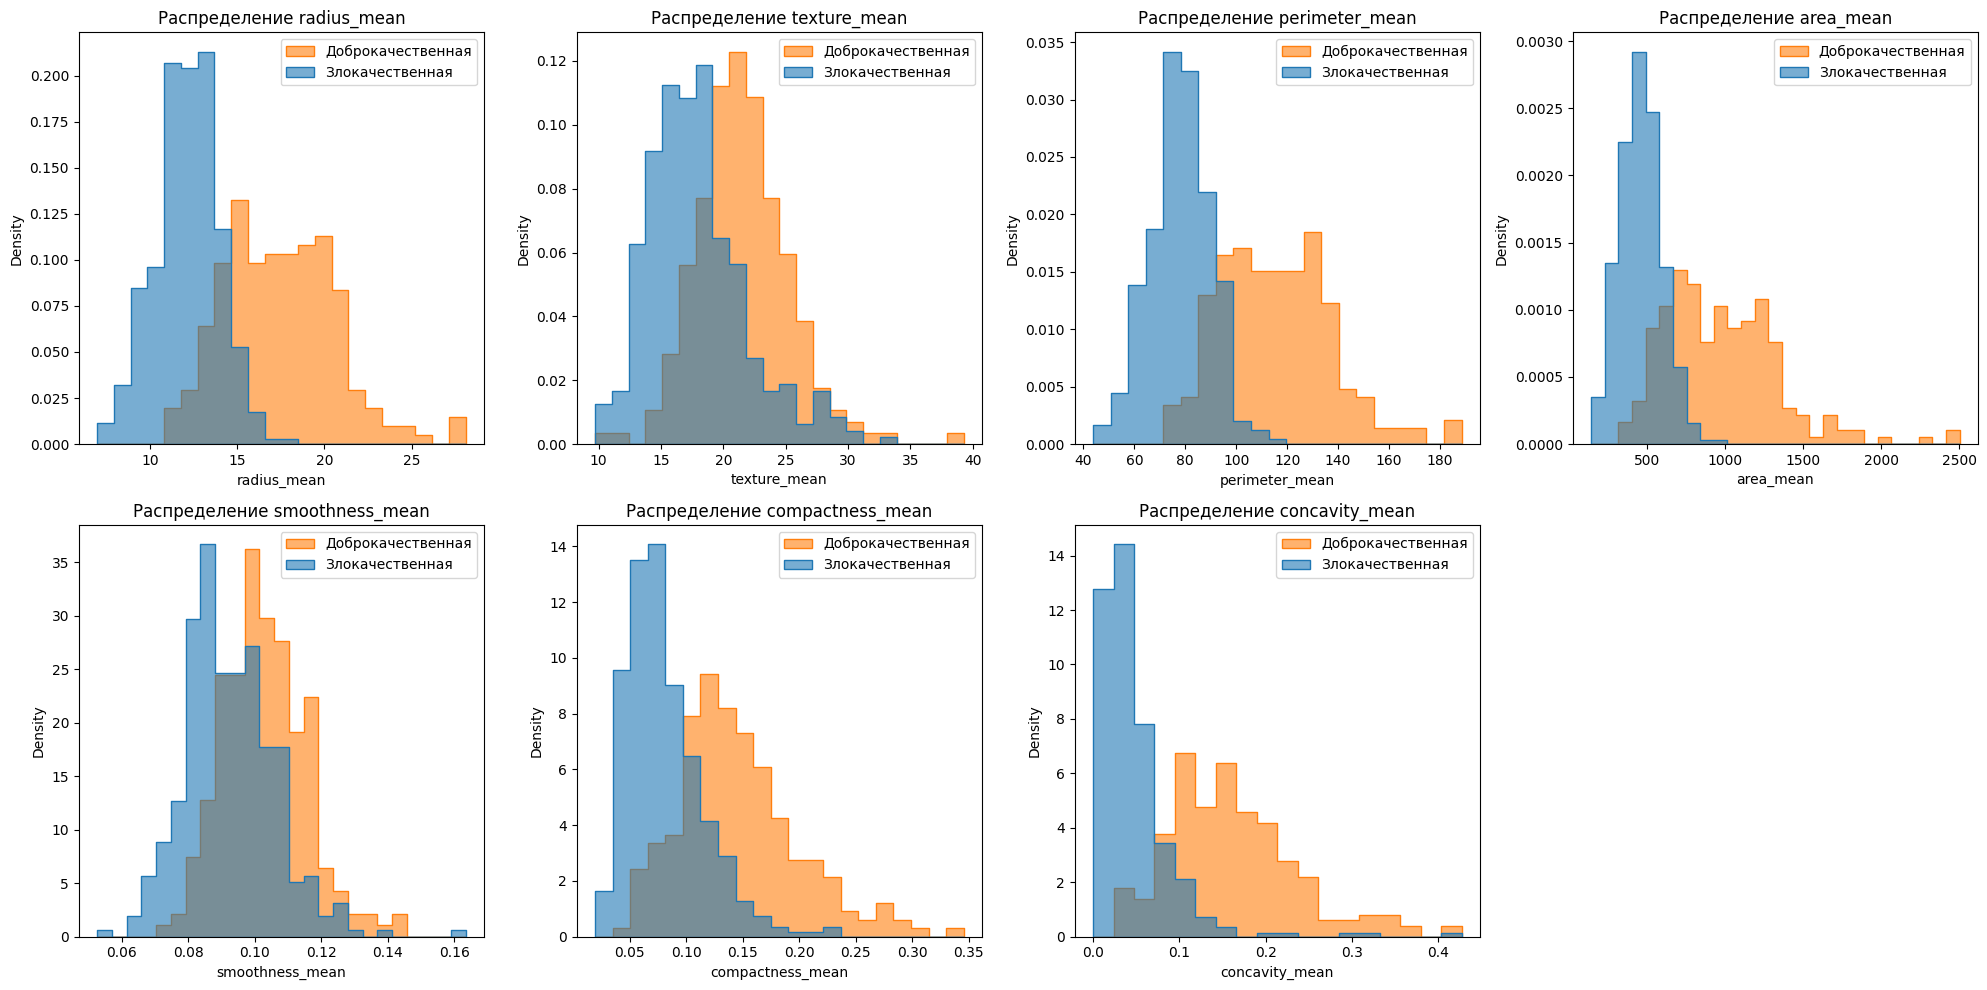

In [37]:
features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 
           'smoothness_mean', 'compactness_mean', 'concavity_mean']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, feature in enumerate(features[:7]):
    sns.histplot(data, x=feature, hue='diagnosis', 
                element='step', stat='density', common_norm=False, 
                alpha=0.6, ax=axes[i])
    axes[i].set_title(f'Распределение {feature}')
    axes[i].legend(['Доброкачественная', 'Злокачественная'])

fig.delaxes(axes[7])
plt.tight_layout() #автоматически регулирует расположение subplot'ов и их элементов на фигуре, чтобы избежать overlapping (перекрытия) и сделать визуализацию более читаемой.
plt.show()

Гистограммы подтверждают, что размерные признаки являются наиболее эффективными для того, чтобы отличать доброкачественную и злокачественную опухоли

In [38]:
correlation_matrix = data.corr()
correlation_matrix.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738


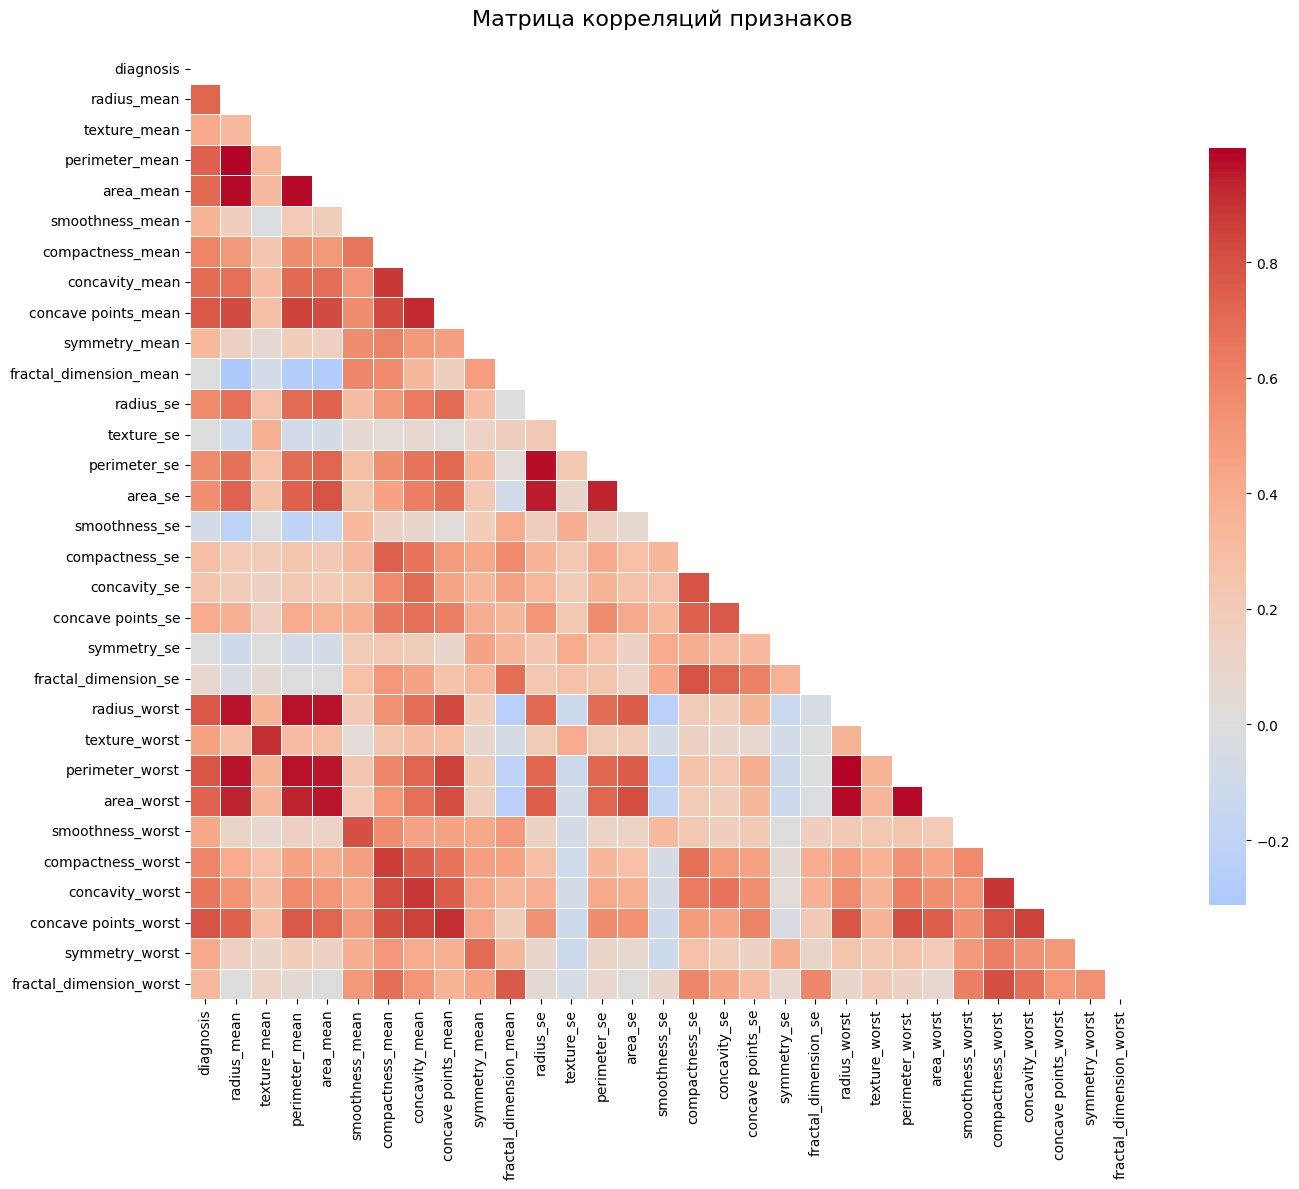

In [39]:
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool)) #triu - верхний треугольник матрицы
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', 
           center=0, square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Матрица корреляций признаков', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [40]:
high_correlation = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.9:
                 high_correlation.append((
                correlation_matrix.columns[i], 
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
                ))
                 
print("Сильно скоррелированные пары признаков (|r| > 0.9):")
for pair in high_correlation:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.3f}")

Сильно скоррелированные пары признаков (|r| > 0.9):
radius_mean - perimeter_mean: 0.998
radius_mean - area_mean: 0.987
radius_mean - radius_worst: 0.970
radius_mean - perimeter_worst: 0.965
radius_mean - area_worst: 0.941
texture_mean - texture_worst: 0.912
perimeter_mean - area_mean: 0.987
perimeter_mean - radius_worst: 0.969
perimeter_mean - perimeter_worst: 0.970
perimeter_mean - area_worst: 0.942
area_mean - radius_worst: 0.963
area_mean - perimeter_worst: 0.959
area_mean - area_worst: 0.959
concavity_mean - concave points_mean: 0.921
concave points_mean - concave points_worst: 0.910
radius_se - perimeter_se: 0.973
radius_se - area_se: 0.952
perimeter_se - area_se: 0.938
radius_worst - perimeter_worst: 0.994
radius_worst - area_worst: 0.984
perimeter_worst - area_worst: 0.978


Высокоскорреклированные признаки: radius_mean/perimeter_mean/area_mean, radius_worst/perimeter_worst/area_worst, radius_se/perimeter_se/area_se. Они измеряют одно и то же - размер опухоли, но в разных единицах измерения и масштабах, поэтому их корреляция ~ 0,99

Признаки внутри каждой группы mean/worst/se содержат избыточную информацию, что показывает высокая корреляция

In [41]:
corr_series = data.corr()['diagnosis'].drop('diagnosis')
sorted_corr = corr_series.abs().sort_values(ascending=False).head(5)
print("Топ-5 самых значимых признаков:")

for feature in sorted_corr.index:
    actual_corr = corr_series[feature]
    abs_corr = abs(actual_corr)
    print(f"  {feature}: {actual_corr:+.6f} (абс.: {abs_corr:.6f})")

Топ-5 самых значимых признаков:
  concave points_worst: +0.793566 (абс.: 0.793566)
  perimeter_worst: +0.782914 (абс.: 0.782914)
  concave points_mean: +0.776614 (абс.: 0.776614)
  radius_worst: +0.776454 (абс.: 0.776454)
  perimeter_mean: +0.742636 (абс.: 0.742636)


Признаки с суффиксом worst доминируют в топе по корреляции с диагнозом, что указывает на их большую диагностическую ценность по сравнению с признаками mean

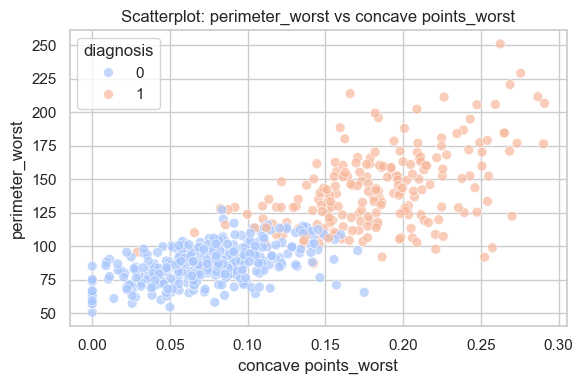

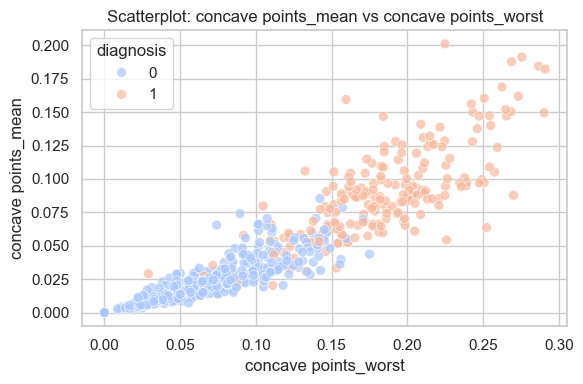

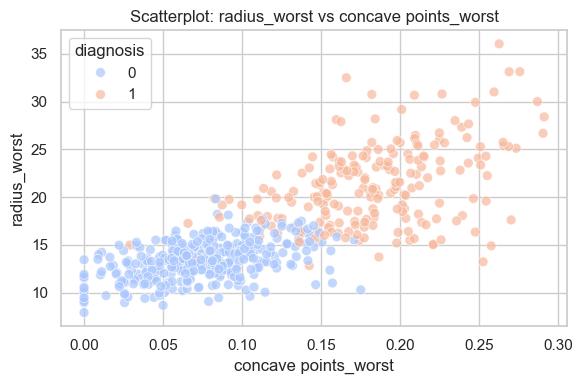

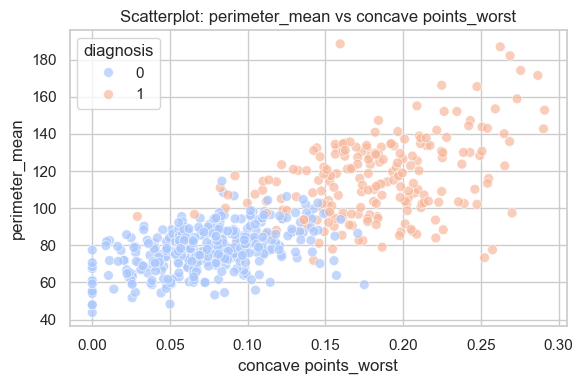

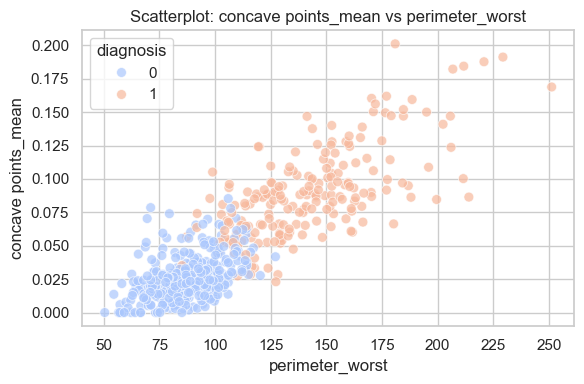

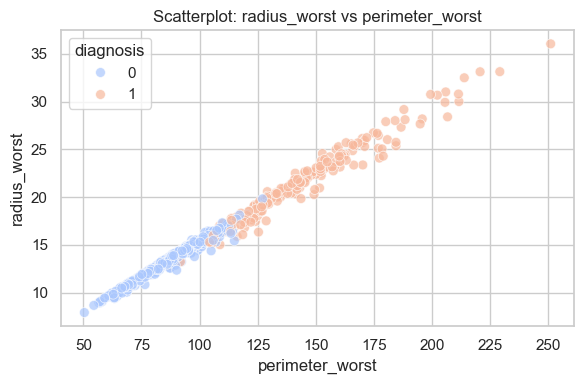

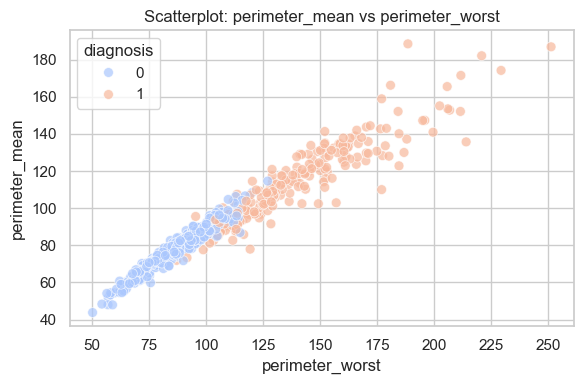

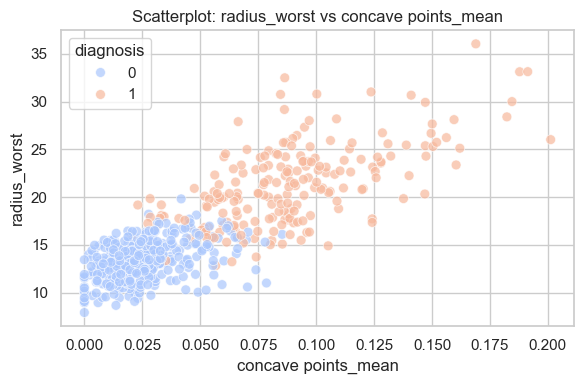

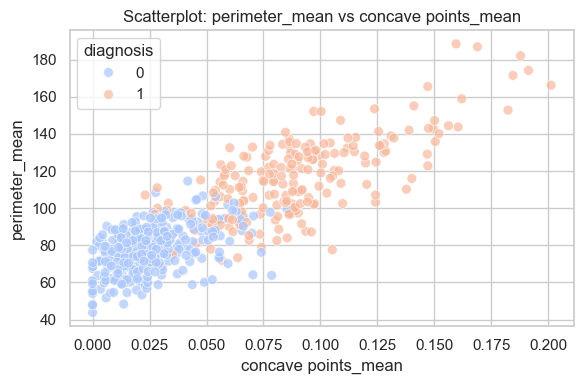

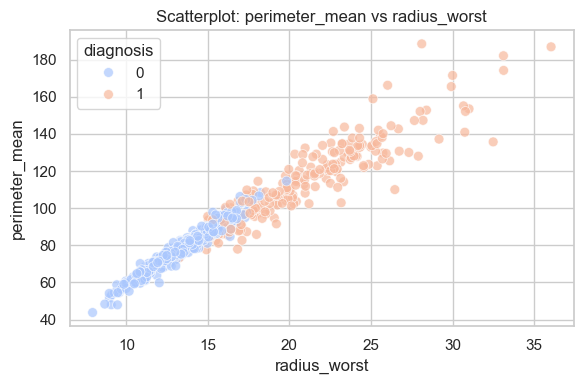

In [48]:
top5_features = [
    'concave points_worst',
    'perimeter_worst',
    'concave points_mean',
    'radius_worst',
    'perimeter_mean'
]
feature_pairs = list(itertools.combinations(top5_features, 2))

for (x_feat, y_feat) in feature_pairs:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(
        data=data,
        x=x_feat,
        y=y_feat,
        hue='diagnosis',
        alpha=0.7,
        s=50,
        palette='coolwarm'
    )
    plt.title(f'Scatterplot: {y_feat} vs {x_feat}')
    plt.tight_layout()
    plt.show()

Злокачественные опухоли сгруппированы в правом верхнем углу — у них значения признаков выше;
Доброкачественные — в левом нижнем углу;
Почти во всех парах признаков видна почти линейная зависимость и хорошая разделимость классов.

In [42]:
corr_series = data.corr()['diagnosis'].drop('diagnosis')
sorted_corr = corr_series.iloc[corr_series.abs().argsort()].head(5)
print("Топ-5 самых малоинформативных признаков:")
for feature, actual_corr in sorted_corr.items():
    abs_corr = abs(actual_corr)
    print(f"  {feature}: {actual_corr:+.6f} (абс.: {abs_corr:.6f})")

Топ-5 самых малоинформативных признаков:
  symmetry_se: -0.006522 (абс.: 0.006522)
  texture_se: -0.008303 (абс.: 0.008303)
  fractal_dimension_mean: -0.012838 (абс.: 0.012838)
  smoothness_se: -0.067016 (абс.: 0.067016)
  fractal_dimension_se: +0.077972 (абс.: 0.077972)


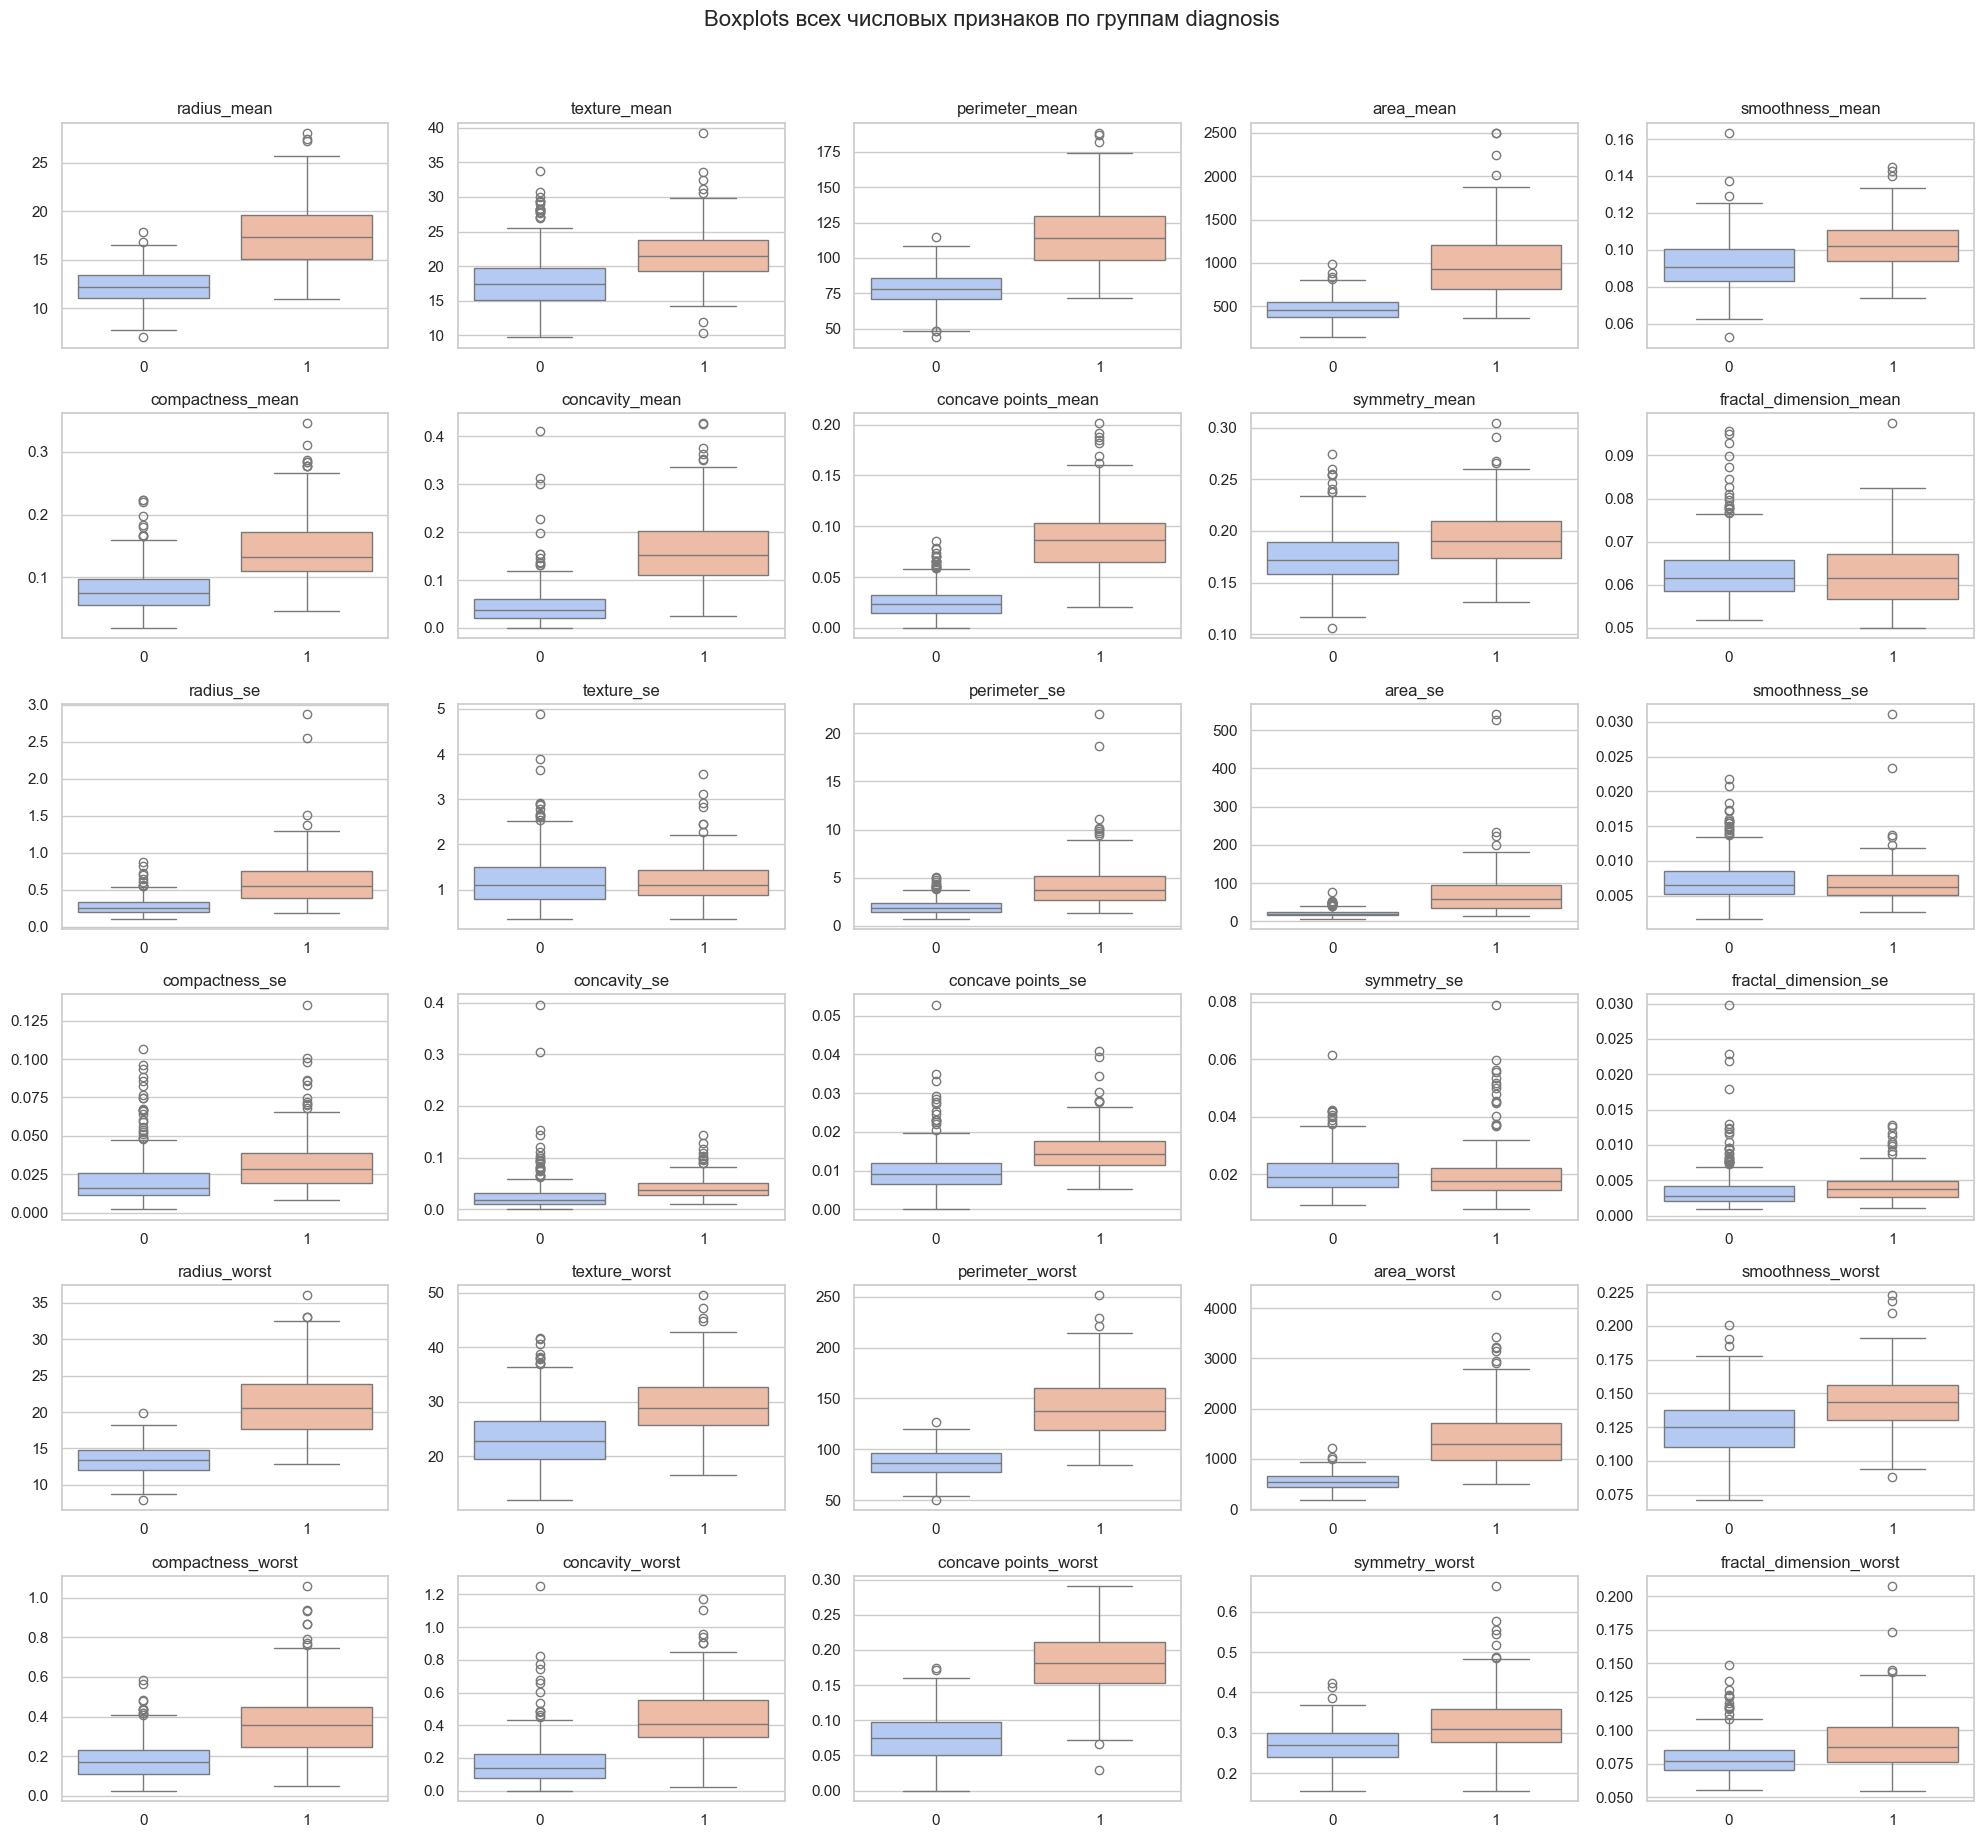

In [51]:
numeric_features = data.columns.drop('diagnosis')

n_cols = 5
n_rows = int(np.ceil(len(numeric_features) / n_cols))

plt.figure(figsize=(n_cols * 4, n_rows * 3))

for i, feature in enumerate(numeric_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=data, x='diagnosis', y=feature, hue='diagnosis', 
                palette='coolwarm', legend=False)
    plt.title(feature)
    plt.xlabel('')
    plt.ylabel('')

plt.suptitle('Boxplots всех числовых признаков по группам diagnosis', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Признаки, где распределения почти не пересекаются — это самые информативные для разделения классов.
Это:
concave points_mean, concave points_worst,
radius_mean, radius_worst,
perimeter_mean, perimeter_worst,
area_mean, area_worst.
Признаки, где "ящики" сильно перекрываются (smoothness_mean, symmetry_mean) дают слабую информацию и могут быть исключены на этапе отбора признаков.

In [52]:
X = data.drop(['diagnosis'], axis=1)
y = data['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Стандартизация необходима, так как kNN использует евклидово расстояние между точками. Без неё признаки с большими числовыми значениями будут доминировать при вычислении расстояний.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       108
           1       0.95      0.94      0.94        63

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



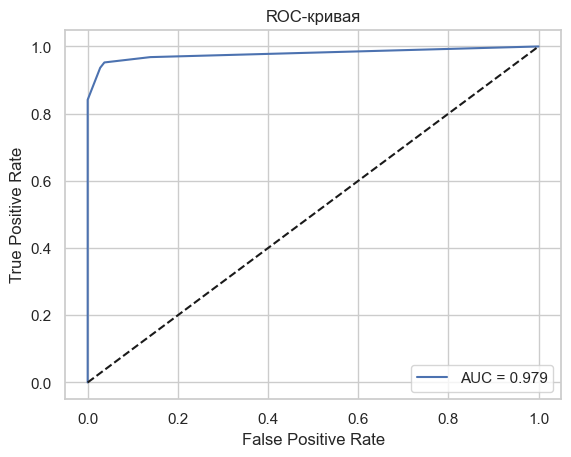

In [56]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
y_pred_proba = knn.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_pred_proba):.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.show()

Размер тестовой выборки: 171 образец
Класс 0 (доброкачественные): 108 образцов
Класс 1 (злокачественные): 63 образца
Метрики качества
Класс 0 (доброкачественные):
Precision (точность): 96% - из всех предсказанных случаев класса 0 96% были верными
Recall (полнота): 97% - модель нашла 97% всех реальных случаев класса 0
F1-score: 97% - сбалансированная оценка точности и полноты
Класс 1 (злокачественные):
Precision: 95% - высокая точность предсказания злокачественных случаев
Recall: 94% - модель обнаружила 94% всех злокачественных случаев
F1-score: 94% - хороший баланс между точностью и полнотой
Общие метрики:
Accuracy (общая точность): 96% - модель правильно классифицировала 96% всех случаев
Macro avg: 96% по всем метрикам - среднее арифметическое по классам
Weighted avg: 96% - среднее с учетом баланса классов
Выводы
Высокая точность модели:
Модель показывает отличные результаты с точностью 96%
Мало ошибок в классификации обоих классов
Сбалансированность:
Метрики для обоих классов очень близки
Нет перекос в сторону какого-либо класса

Оптимальное k: {'n_neighbors': 3}
Точность на кросс-валидации: 0.960
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       108
           1       0.95      0.94      0.94        63

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



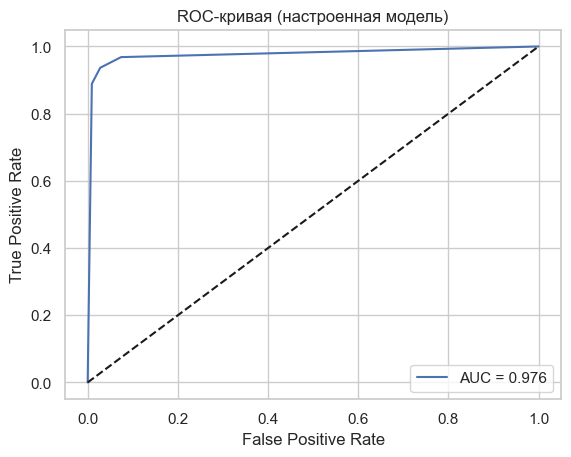

In [58]:
param_grid = {'n_neighbors': range(1, 31)}
knn_tuned = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
knn_tuned.fit(X_train_scaled, y_train)

# Результаты
print(f'Оптимальное k: {knn_tuned.best_params_}')
print(f'Точность на кросс-валидации: {knn_tuned.best_score_:.3f}')

# Оценка на тесте
y_pred_tuned = knn_tuned.predict(X_test_scaled)
print(classification_report(y_test, y_pred_tuned))

# ROC-кривая для настроенной модели
y_pred_proba_tuned = knn_tuned.predict_proba(X_test_scaled)[:, 1]
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_pred_proba_tuned)
plt.figure()
plt.plot(fpr_tuned, tpr_tuned, label=f'AUC = {roc_auc_score(y_test, y_pred_proba_tuned):.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая (настроенная модель)')
plt.legend()
plt.show()

Оптимальные параметры:
Найденное оптимальное значение k = 3
Точность на кросс-валидации: 96.0%
Метрики качества:
Класс 0 (доброкачественные):
Precision: 96% - из всех предсказанных случаев класса 0 96% были верными
Recall: 97% - модель нашла 97% всех реальных случаев класса 0
F1-score: 97% - сбалансированная оценка точности и полноты
Класс 1 (злокачественные):
Precision: 95% - высокая точность предсказания злокачественных случаев
Recall: 94% - модель обнаружила 94% всех злокачественных случаев
F1-score: 94% - хороший баланс между точностью и полнотой
Общие метрики:
Accuracy: 96% - модель правильно классифицировала 96% всех случаев
Macro avg: 96% по всем метрикам - среднее арифметическое по классам
Weighted avg: 96% - среднее с учетом баланса классов
Выводы по результатам:
Качество модели:
Достигнута очень высокая точность классификации (96%)
Модель показывает сбалансированные результаты по обоим классам
Высокий recall для злокачественных случаев (94%) важен для медицинской диагностики
Влияние настройки параметров:
Выбор k=3 оказался оптимальным
Метрики качества после настройки остались на высоком уровне
Незначительное улучшение по сравнению с базовой моделью